In [ ]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt

# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
from os import path
import zipfile
import requests
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "fried_rice_chicken_curry_dumplings_donuts100_percent"
if image_path.is_dir():
  print(f"{image_path} exist")
else:
  print(f"creating {image_path} directory")
  image_path.mkdir(parents=True,exist_ok=True)
  with open(data_path / "fried_rice_chicken_curry_dumplings_donuts100_percent.zip", 'wb') as f:
    print(f"downloading data.....")
    request = requests.get("https://github.com/AvisarBhandari/Ml/raw/main/Custom%20data/data/fried_rice_chicken_curry_dumplings_donuts100_percent.zip")
    f.write(request.content)
  with zipfile.ZipFile(data_path / "fried_rice_chicken_curry_dumplings_donuts100_percent.zip",'r') as zip_ref:
    print(f"extracting Zipfile...")
    zip_ref.extractall(image_path)
    print("removing zipfile...")
    Path(data_path / "fried_rice_chicken_curry_dumplings_donuts100_percent.zip").unlink(missing_ok=True)

creating data/fried_rice_chicken_curry_dumplings_donuts100_percent directory
downloading data.....
extracting Zipfile...
removing zipfile...


In [ ]:
train_dir = image_path / "train"
test_dir = image_path / "test"
val_dir = image_path / "val"
train_dir , test_dir , val_dir

(PosixPath('data/fried_rice_chicken_curry_dumplings_donuts100_percent/train'),
 PosixPath('data/fried_rice_chicken_curry_dumplings_donuts100_percent/test'),
 PosixPath('data/fried_rice_chicken_curry_dumplings_donuts100_percent/val'))

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
train_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

Random image path: data/fried_rice_chicken_curry_dumplings_donuts100_percent/train/donuts/3611291.jpg
Image class: donuts
Image height: 512
Image width: 512


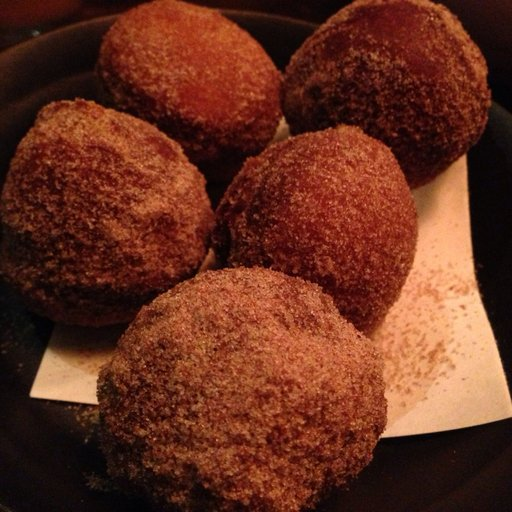

In [ ]:
import random
from PIL import Image
# set a seed
random.seed(42)
# get all the image path
image_path_list = list(image_path.glob("*/*/*.jpg"))
# get rangom image path
random_image_path = random.choice(image_path_list)
# get class from the path
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

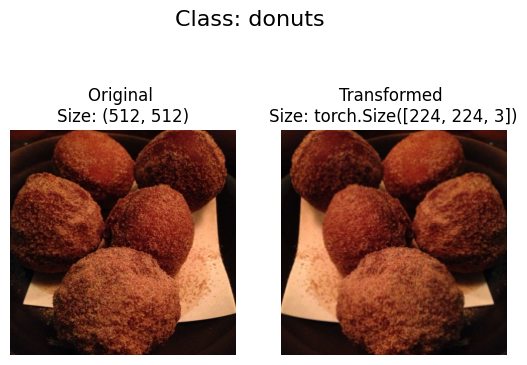

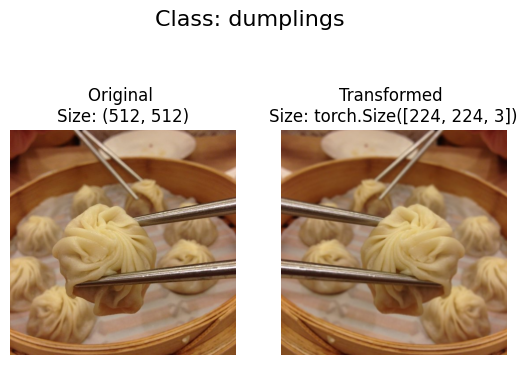

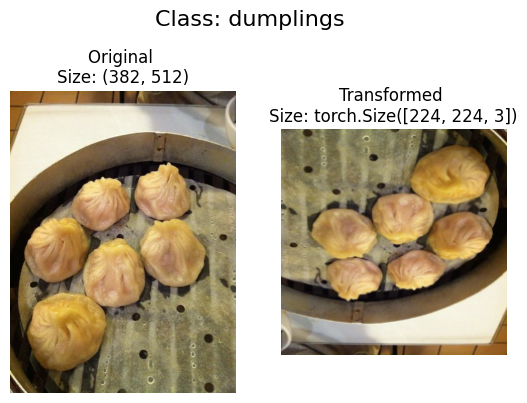

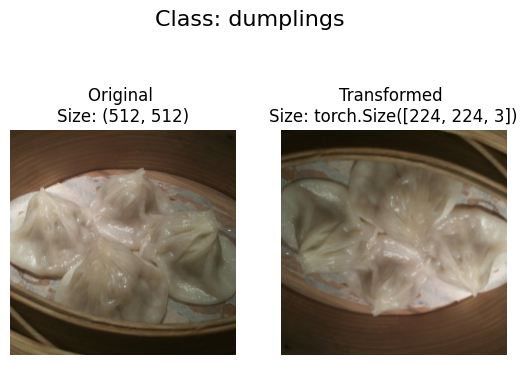

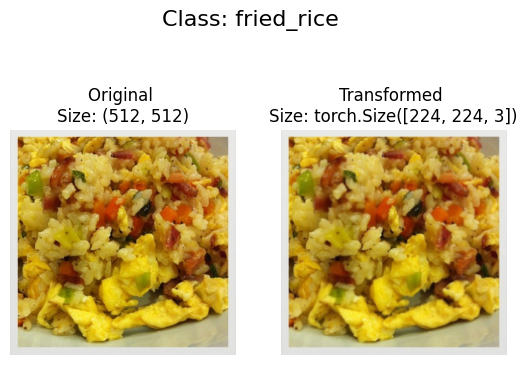

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=train_transform,
                        n=5)

In [ ]:
train_data = datasets.ImageFolder(root=train_dir,transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=train_transform)
val_data = datasets.ImageFolder(root=val_dir, transform=train_transform)

In [ ]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names, class_dict

(['chicken_curry', 'donuts', 'dumplings', 'fried_rice'],
 {'chicken_curry': 0, 'donuts': 1, 'dumplings': 2, 'fried_rice': 3})

In [ ]:
len(train_data), len(test_data), len(val_data)

(3000, 500, 500)

In [ ]:
import os
BATCH_SIZE = 32
NUM_WORKRS = os.cpu_count()
train_dataloader = DataLoader(dataset=train_data,batch_size=BATCH_SIZE,num_workers=NUM_WORKRS,shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, num_workers=NUM_WORKRS)
val_dataloader = DataLoader(dataset=val_data, batch_size=BATCH_SIZE, num_workers=NUM_WORKRS)

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               ):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch, (x, y) in enumerate(dataloader):
    # Send data to target device
    x, y = x.to(device), y.to(device)
    # 1. Forward pass
    train_logits = model(x)
    # 2. Calculate and accumulate loss
    loss = loss_fn(train_logits,y)
    train_loss +=loss.item()
    # 3. Optimizer zero grad
    optimizer.zero_grad()
    # 4. Loss backward
    loss.backward()
    # 5. Optimizer step
    optimizer.step()
    # Calculate and accumualte accuracy metric across all batches
    y_pred_class = torch.argmax(torch.softmax(train_logits,dim=1),dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(train_logits)

  # Adjust metrics to get average loss and average accuracy per batch
  train_loss = train_loss/len(dataloader)
  train_acc = train_acc/len(dataloader)

  return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch,(x,y) in enumerate(dataloader):
      # Send data to target device
      x, y = x.to(device), y.to(device)
      # 1. Forward pass
      test_logits = model(x)
      # 2. Calculuate and accumulate loss
      loss = loss_fn(test_logits, y)
      test_loss += loss.item()
      # Calculate and accumulate accuracy
      y_pred_class = torch.argmax(torch.softmax(test_logits,dim=1),dim=1)
      test_acc += (y_pred_class == y ).sum().item() / len(test_logits)
  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [ ]:
def val_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  # Put model in eval mode
  model.eval()

  # Setup the val loss and val accuracy values
  val_loss, val_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch,(x,y) in enumerate(dataloader):
      # Send data to target device
      x, y = x.to(device), y.to(device)
      # 1. Forward pass
      val_logits = model(x)
      # 2. Calculuate and accumulate loss
      loss = loss_fn(val_logits, y)
      val_loss += loss.item()
      # Calculate and accumulate accuracy
      y_pred_class = torch.argmax(torch.softmax(val_logits,dim=1),dim=1)
      val_acc += (y_pred_class == y ).sum().item() / len(val_logits)
  # Adjust metrics to get average loss and accuracy per batch
  val_loss = val_loss / len(dataloader)
  val_acc = val_acc / len(dataloader)
  return val_loss, val_acc

In [ ]:
def train(MODEL_SAVE_PATH: str,
          model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          scheduler: torch.optim.lr_scheduler = None
          ):

  results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "val_loss": [], "val_acc": []}

  best_val_loss = 100
  improvement_counter = 5
  Path("model").mkdir(exist_ok=True)
  for epoch in tqdm(range(epochs)):
    if improvement_counter >= 0:

      # Update the learning rate if a scheduler is provided

      train_loss, train_acc = train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer)
      test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
      val_loss, val_acc = val_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
      # Update the learning rate if a scheduler is provided
      if scheduler:
          scheduler.step(val_loss)
      if val_loss < best_val_loss:
        best_val_loss = val_loss
        improvement_counter = 5
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"New Best model found ({best_val_loss}) and Saved")
      else:
        best_val_loss = val_loss

      print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f} | \n val_loss: {val_loss} | val_acc: {val_acc} | LR: {optimizer.param_groups[0]['lr']:.6f}\n patience : {improvement_counter}")

      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)
      results["val_loss"].append(val_loss)
      results["val_acc"].append(val_acc)
      improvement_counter-=1
    else:
      print(f"traning stop as model did not improved")

  return results

In [ ]:
from typing import Dict, List
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']
    val_loss = results['val_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    val_acc = results['val_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.plot(epochs, val_acc, label='val_acc')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
model_0 = efficientnet_b0(weights=EfficientNet_B0_Weights)
for param in model_0.features.parameters():
  param.requires_grad = False
  weights = EfficientNet_B0_Weights.DEFAULT
  model_0.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features=1280, out_features=len(class_names))
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
MODEL_0_SAVE_PATH = "model/best_model_0.pth"

In [ ]:
from tqdm.auto import tqdm
import json
# Train for 10 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS=3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()
# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        val_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        MODEL_SAVE_PATH=MODEL_0_SAVE_PATH)

# End the timer and print out how long it took
end_time = timer()
with open("model_0_results.json", "w") as f:
    json.dump(model_0_results, f)
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

New Best model found (0.29419129993766546) and Saved
Epoch: 1 | train_loss: 0.3574 | train_acc: 0.8787 | test_loss: 0.2843 | test_acc: 0.9062 | 
 val_loss: 0.29419129993766546 | val_acc: 0.89609375 | LR: 0.001000
 patience : 5
New Best model found (0.26564554776996374) and Saved
Epoch: 2 | train_loss: 0.3662 | train_acc: 0.8808 | test_loss: 0.2855 | test_acc: 0.9070 | 
 val_loss: 0.26564554776996374 | val_acc: 0.925390625 | LR: 0.001000
 patience : 5
New Best model found (0.24454796314239502) and Saved
Epoch: 3 | train_loss: 0.3841 | train_acc: 0.8638 | test_loss: 0.2492 | test_acc: 0.9258 | 
 val_loss: 0.24454796314239502 | val_acc: 0.924609375 | LR: 0.001000
 patience : 5
Epoch: 4 | train_loss: 0.3808 | train_acc: 0.8616 | test_loss: 0.2611 | test_acc: 0.9164 | 
 val_loss: 0.28160622296854854 | val_acc: 0.913671875 | LR: 0.001000
 patience : 4
New Best model found (0.2523371228016913) and Saved
Epoch: 5 | train_loss: 0.3735 | train_acc: 0.8658 | test_loss: 0.2654 | test_acc: 0.9164 |

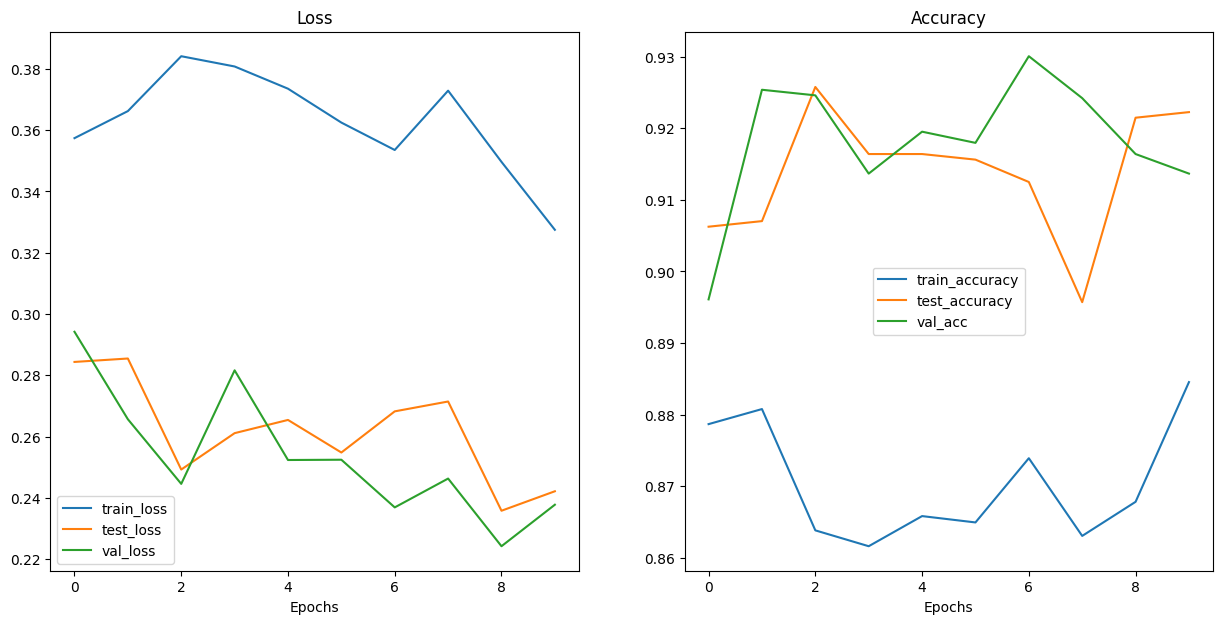

In [ ]:
plot_loss_curves(model_0_results)

In [ ]:
best_model_0 = model_0
best_model_0.load_state_dict(torch.load(MODEL_0_SAVE_PATH))
# test_step(model=best_model_0,dataloader=test_dataloader,loss_fn=loss_fn)

<All keys matched successfully>

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
model_1 = efficientnet_b0(weights=EfficientNet_B0_Weights)
for param in model_1.features[-1].parameters():
  param.requires_grad = True
  model_1.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features=1280, out_features=len(class_names))
)

In [ ]:
MODEL_1_SAVE_PATH = "model/best_unfreezer_model_0.pth"

In [ ]:
from tqdm.auto import tqdm
# Train for 10 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS=10

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=1e-6)

# Start the timer
from timeit import default_timer as timer
start_time = timer()
# Train model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        val_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        MODEL_SAVE_PATH=MODEL_1_SAVE_PATH)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

New Best model found (1.3319308832287788) and Saved
Epoch: 1 | train_loss: 1.3690 | train_acc: 0.3128 | test_loss: 1.3333 | test_acc: 0.3805 | 
 val_loss: 1.3319308832287788 | val_acc: 0.3734375 | LR: 0.000001
 patience : 5
New Best model found (1.309283807873726) and Saved
Epoch: 2 | train_loss: 1.3440 | train_acc: 0.3487 | test_loss: 1.3162 | test_acc: 0.4180 | 
 val_loss: 1.309283807873726 | val_acc: 0.434765625 | LR: 0.000001
 patience : 5
New Best model found (1.2996854409575462) and Saved
Epoch: 3 | train_loss: 1.3207 | train_acc: 0.3854 | test_loss: 1.2894 | test_acc: 0.4691 | 
 val_loss: 1.2996854409575462 | val_acc: 0.440625 | LR: 0.000001
 patience : 5
New Best model found (1.275078497827053) and Saved
Epoch: 4 | train_loss: 1.3044 | train_acc: 0.4286 | test_loss: 1.2768 | test_acc: 0.4824 | 
 val_loss: 1.275078497827053 | val_acc: 0.49375 | LR: 0.000001
 patience : 5
New Best model found (1.2490559369325638) and Saved
Epoch: 5 | train_loss: 1.2906 | train_acc: 0.4454 | test_

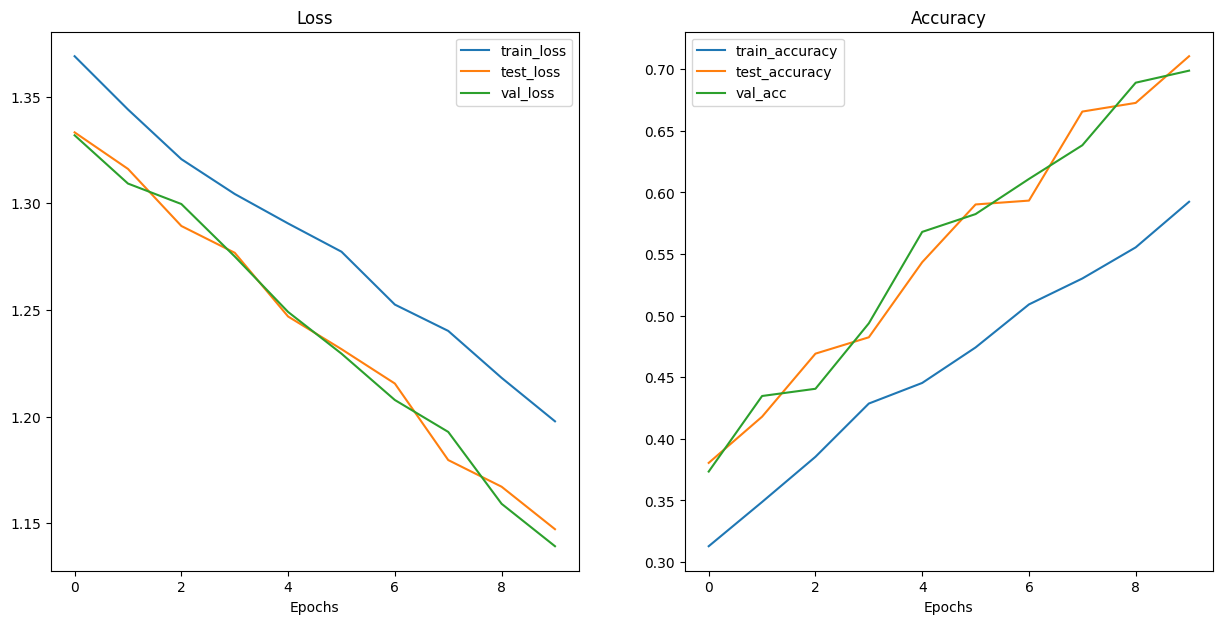

In [ ]:
plot_loss_curves(model_1_results)

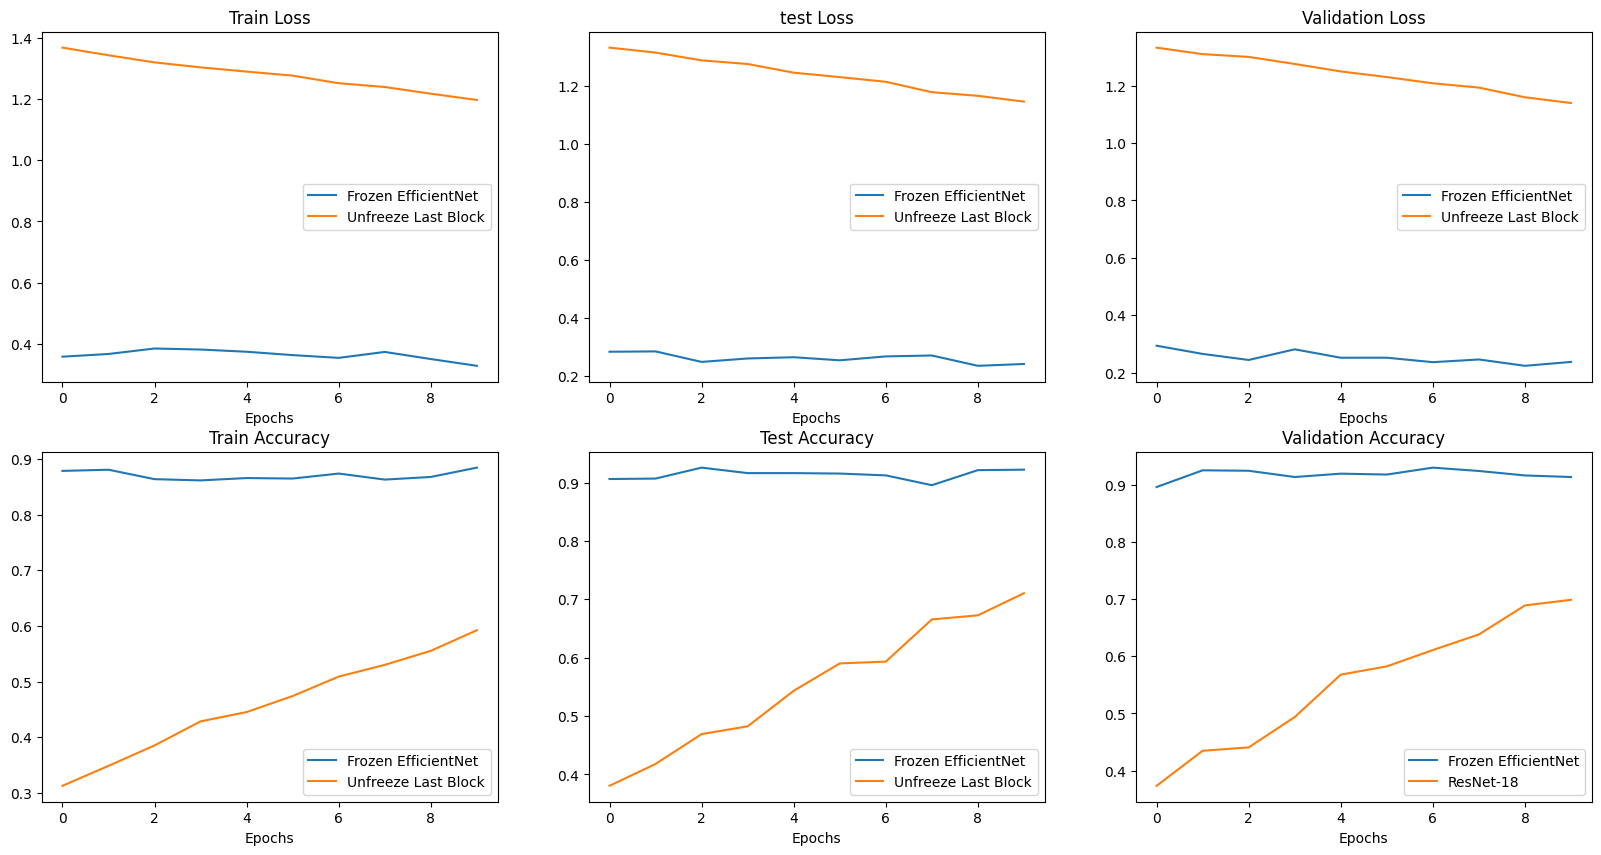

In [ ]:
plt.figure(figsize=(20,10))

epochs = range(10)

# plot train loss
plt.subplot(2,3,1)
plt.plot(epochs,model_0_results["train_loss"],label="Frozen EfficientNet")
plt.plot(epochs,model_1_results["train_loss"],label="Unfreeze Last Block")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()
# plot test loss
plt.subplot(2,3,2)
plt.plot(epochs,model_0_results["test_loss"],label="Frozen EfficientNet")
plt.plot(epochs,model_1_results["test_loss"],label="Unfreeze Last Block")
plt.title("test Loss")
plt.xlabel("Epochs")
plt.legend()
# plot val loss
plt.subplot(2,3,3)
plt.plot(epochs,model_0_results["val_loss"],label="Frozen EfficientNet")
plt.plot(epochs,model_1_results["val_loss"],label="Unfreeze Last Block")
plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.legend()
# plot train accuracy
plt.subplot(2,3,4)
plt.plot(epochs,model_0_results["train_acc"],label="Frozen EfficientNet")
plt.plot(epochs,model_1_results["train_acc"],label="Unfreeze Last Block")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()
# plot test accuracy
plt.subplot(2,3,5)
plt.plot(epochs,model_0_results["test_acc"],label="Frozen EfficientNet")
plt.plot(epochs,model_1_results["test_acc"],label="Unfreeze Last Block")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend()
# plot validation accuracy
plt.subplot(2,3,6)
plt.plot(epochs,model_0_results["val_acc"],label="Frozen EfficientNet")
plt.plot(epochs,model_1_results["val_acc"],label="ResNet-18")
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
from inspect import classify_class_attrs
from torchvision import transforms
from PIL import Image
def predict_image(f:str,model:torch.nn.Module):
  model.eval()
  transform = weights.transforms()
  result ={"name":[],"pred":[]}
  img = Image.open(f).convert("RGB")
  img_tensor = transform(img)

  img_tensor = img_tensor.unsqueeze(0).to(device)
  with torch.inference_mode():
    prob_logit = model(img_tensor)
    prob = (torch.softmax(prob_logit,dim=1)).squeeze()
    prob_label = torch.argmax(prob_logit,dim=1).item()
    prob_label = class_names[prob_label]
    top_probs, top_indices = torch.topk(prob, k=3)

  for i in range(len(top_probs)):
    name = class_names[top_indices[i].item()]
    percentage = round(top_probs[i].item()*100)
    result["name"].append(name)
    result["pred"].append(percentage)
  return result


In [ ]:
import random
image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)

Real Class : fried_rice
{'name': ['fried_rice', 'donuts', 'chicken_curry'], 'pred': [29, 27, 23]}


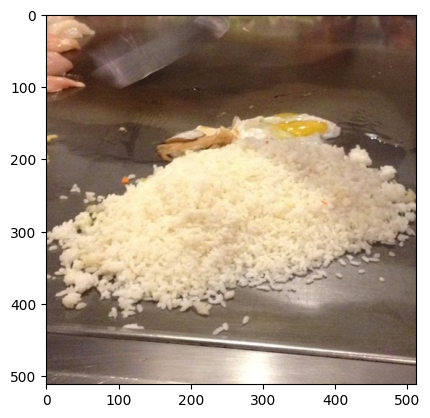

In [ ]:

print(f"Real Class : {random_image_path.parent.name}")
# top_probs, top_indices = predict_image(random_image_path,model_0)
print( predict_image(random_image_path,model_0))
img = Image.open(random_image_path)
plt.imshow(img)